## Lendo o arquivo de distancias

In [50]:
import json
import pandas as pd

distances_file_name = "distances_1_3.json"

In [51]:
with open(distances_file_name, "r") as f:
    distances = json.load(f)

## Calculando a média de cada distância

In [52]:
distances_df = pd.DataFrame(distances)
distances_df.head()

,file_name,fft_distance,stft_distance,log_mel_spectrogram_distance_raw,log_mel_spectrogram_distance_normalized,log_mel_num_elements
0,keyboard_electronic_001-040-075.wav,13523.025391,2519.593750,170.269913,0.010557,16128
1,keyboard_synthetic_000-047-050.wav,8786.061523,1758.104370,96.202583,0.005965,16128
2,vocal_acoustic_000-060-050.wav,15093.957031,2623.630615,154.657394,0.009589,16128
3,brass_acoustic_006-042-075.wav,15490.542969,2681.092041,185.372238,0.011494,16128
4,keyboard_electronic_078-044-100.wav,12947.949219,2385.653564,171.534653,0.010636,16128


In [53]:
# Médias e desvios das métricas
mean_fft = distances_df['fft_distance'].mean()
std_fft = distances_df['fft_distance'].std()

mean_stft = distances_df['stft_distance'].mean()
std_stft = distances_df['stft_distance'].std()

mean_logmel_raw = distances_df['log_mel_spectrogram_distance_raw'].mean()
std_logmel_raw = distances_df['log_mel_spectrogram_distance_raw'].std()

mean_logmel_norm = distances_df['log_mel_spectrogram_distance_normalized'].mean()
std_logmel_norm = distances_df['log_mel_spectrogram_distance_normalized'].std()

print(f"Média FFT: {mean_fft}")
print(f"Desvio padrão FFT: {std_fft}")
print(f"Média STFT: {mean_stft}")
print(f"Desvio padrão STFT: {std_stft}")
print(f"Média Log Mel (raw): {mean_logmel_raw}")
print(f"Desvio padrão Log Mel (raw): {std_logmel_raw}")
print(f"Média Log Mel (normalizado): {mean_logmel_norm}")
print(f"Desvio padrão Log Mel (normalizado): {std_logmel_norm}")

Média FFT: 14922.712599992752
Desvio padrão FFT: 6317.634459993051
Média STFT: 2742.8608128279448
Desvio padrão STFT: 1086.3336241957602
Média Log Mel (raw): 144.5833555208519
Desvio padrão Log Mel (raw): 50.418115818386326
Média Log Mel (normalizado): 0.00896474178665585
Desvio padrão Log Mel (normalizado): 0.003126123255369073


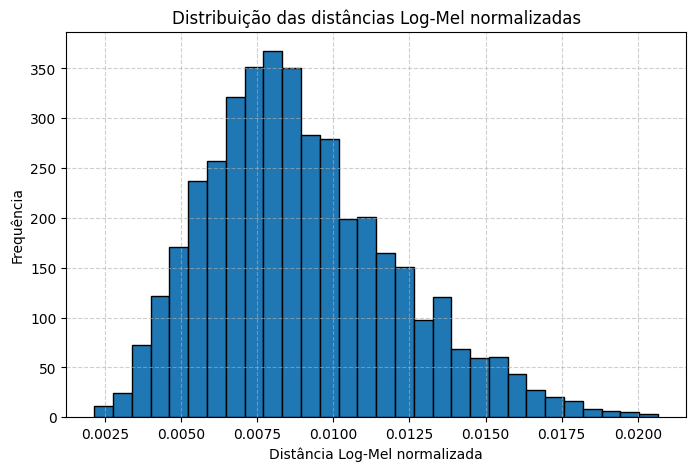

In [54]:
import pandas as pd
import matplotlib.pyplot as plt

# carregar o JSON salvo
distances_df = pd.read_json(distances_file_name)

# histograma da métrica log-mel normalizada
plt.figure(figsize=(8, 5))
plt.hist(
    distances_df["log_mel_spectrogram_distance_normalized"],
    bins=30,
    edgecolor="black"
)
plt.title("Distribuição das distâncias Log-Mel normalizadas")
plt.xlabel("Distância Log-Mel normalizada")
plt.ylabel("Frequência")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


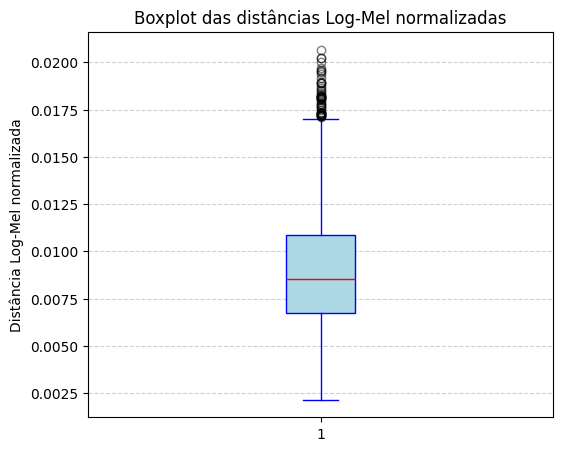

In [55]:
import pandas as pd
import matplotlib.pyplot as plt

# carregar o JSON salvo
distances_df = pd.read_json(distances_file_name)

# boxplot da métrica log-mel normalizada
plt.figure(figsize=(6, 5))
plt.boxplot(
    distances_df["log_mel_spectrogram_distance_normalized"],
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor="lightblue", color="blue"),
    medianprops=dict(color="red"),
    whiskerprops=dict(color="blue"),
    capprops=dict(color="blue"),
    flierprops=dict(marker="o", color="gray", alpha=0.5),
)
plt.title("Boxplot das distâncias Log-Mel normalizadas")
plt.ylabel("Distância Log-Mel normalizada")
plt.grid(True, linestyle="--", alpha=0.6, axis="y")
plt.show()


In [56]:
import pandas as pd

# carregar JSON salvo
distances_df = pd.read_json(distances_file_name)

# estatísticas descritivas para a métrica log-mel normalizada
summary_stats = {
    "mean": distances_df["log_mel_spectrogram_distance_normalized"].mean(),
    "std": distances_df["log_mel_spectrogram_distance_normalized"].std(),
    "min": distances_df["log_mel_spectrogram_distance_normalized"].min(),
    "p25": distances_df["log_mel_spectrogram_distance_normalized"].quantile(0.25),
    "median": distances_df["log_mel_spectrogram_distance_normalized"].median(),
    "p75": distances_df["log_mel_spectrogram_distance_normalized"].quantile(0.75),
    "p90": distances_df["log_mel_spectrogram_distance_normalized"].quantile(0.90),
    "p95": distances_df["log_mel_spectrogram_distance_normalized"].quantile(0.95),
    "max": distances_df["log_mel_spectrogram_distance_normalized"].max(),
}

summary_df = pd.DataFrame(summary_stats, index=["log_mel_norm"])
print(summary_df.T)


        log_mel_norm
mean        0.008965
std         0.003126
min         0.002145
p25         0.006723
median      0.008536
p75         0.010856
p90         0.013442
p95         0.014856
max         0.020666


## Calculate grouped metrics

In [57]:
import pandas as pd

# criar coluna de grupo pela primeira palavra do file_name
distances_df["group"] = distances_df["file_name"].str.split("_").str[0]

# calcular estatísticas por grupo
group_stats = distances_df.groupby("group").agg(
    mean_fft=("fft_distance", "mean"),
    mean_stft=("stft_distance", "mean"),
    mean_logmel_raw=("log_mel_spectrogram_distance_raw", "mean"),
    mean_logmel_norm=("log_mel_spectrogram_distance_normalized", "mean"),
    std_fft=("fft_distance", "std"),
    std_stft=("stft_distance", "std"),
    std_logmel_raw=("log_mel_spectrogram_distance_raw", "std"),
    std_logmel_norm=("log_mel_spectrogram_distance_normalized", "std"),
)

print(group_stats)

              mean_fft    mean_stft  mean_logmel_raw  mean_logmel_norm  \
group                                                                    
bass      13143.576693  2515.476117       135.973962          0.008431   
brass     16572.937175  3002.279192       175.395484          0.010875   
flute     17408.116683  3370.179231       155.879037          0.009665   
guitar    12360.566629  2302.765898       124.079500          0.007693   
keyboard  11448.490462  2111.679971       122.187746          0.007576   
mallet    10287.649165  2082.933867       114.875078          0.007123   
organ     21787.615192  3956.711510       191.581305          0.011879   
reed      15433.472523  2626.735255       147.759078          0.009162   
string    15556.318112  2783.158653       151.918930          0.009420   
vocal     29933.291320  5000.459461       193.354311          0.011989   

              std_fft     std_stft  std_logmel_raw  std_logmel_norm  
group                                    